In [46]:
# =========================
# Cell 1: Imports
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [51]:
# =========================
# Cell 2: Upload dataset
# =========================
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("Dataset shape:", df.shape)
df.head()

Saving cardekho_dataset.csv to cardekho_dataset (3).csv
Dataset shape: (15411, 14)


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [48]:
# =========================
# Cell 3: Basic inspection
# =========================
print("Columns:")
print(df.columns.tolist())

print("\nInfo:")
print(df.info())

print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())

Columns:
['Model', 'MAE', 'MSE', 'RMSE', 'R2 Score']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Model     3 non-null      object 
 1   MAE       3 non-null      float64
 2   MSE       3 non-null      float64
 3   RMSE      3 non-null      float64
 4   R2 Score  3 non-null      float64
dtypes: float64(4), object(1)
memory usage: 252.0+ bytes
None

Missing values:
Model       0
MAE         0
MSE         0
RMSE        0
R2 Score    0
dtype: int64

Duplicate rows: 0


In [52]:
# =========================
# Cell 4: Clean dataset
# =========================
# Drop index-like column
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Target column
target_col = "selling_price"

# Drop duplicate rows
df = df.drop_duplicates().copy()

# Make sure target is numeric
df[target_col] = pd.to_numeric(df[target_col], errors="coerce")

# Drop rows where target is missing, if any
df = df.dropna(subset=[target_col]).copy()

print("Shape after cleaning:", df.shape)
df.head()

Shape after cleaning: (15244, 13)


,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [53]:
# =========================
# Cell 5: Feature engineering
# =========================
# In your dataset, most useful features are already present.
# We can create a few extra features from existing columns.

# Price per engine power ratio (optional feature)
if "max_power" in df.columns and "engine" in df.columns:
    df["power_to_engine_ratio"] = df["max_power"] / (df["engine"] + 1)

# Log transform of km_driven can help if skewed
if "km_driven" in df.columns:
    df["km_driven_log"] = np.log1p(df["km_driven"])

print("Columns after feature engineering:")
print(df.columns.tolist())

Columns after feature engineering:
['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price', 'power_to_engine_ratio', 'km_driven_log']


In [54]:
# =========================
# Cell 6: Define X and y
# =========================
X = df.drop(columns=[target_col])
y = df[target_col]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature types:")
print(X.dtypes)

Features shape: (15244, 14)
Target shape: (15244,)

Feature types:
car_name                  object
brand                     object
model                     object
vehicle_age                int64
km_driven                  int64
seller_type               object
fuel_type                 object
transmission_type         object
mileage                  float64
engine                     int64
max_power                float64
seats                      int64
power_to_engine_ratio    float64
km_driven_log            float64
dtype: object


In [55]:
# =========================
# Cell 7: Train-test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (12195, 14)
Testing set: (3049, 14)


In [56]:
# =========================
# Cell 8: Preprocessing
# =========================
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# For linear regression: scale numeric features
numeric_transformer_linear = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# For tree-based models: scaling not required
numeric_transformer_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_linear = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_linear, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_tree, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Numeric features: ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'power_to_engine_ratio', 'km_driven_log']
Categorical features: ['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']


In [57]:
# =========================
# Cell 9: Build models
# =========================
models = {
    "Linear Regression": Pipeline(steps=[
        ("preprocessor", preprocessor_linear),
        ("model", LinearRegression())
    ]),

    "Decision Tree Regressor": Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("model", DecisionTreeRegressor(
            random_state=42,
            max_depth=12
        ))
    ]),

    "Random Forest Regressor": Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("model", RandomForestRegressor(
            n_estimators=50,
            max_depth=10,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ])
}

In [58]:
# =========================
# Cell 10: Train models
# =========================
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained successfully.")

Linear Regression trained successfully.
Decision Tree Regressor trained successfully.
Random Forest Regressor trained successfully.


In [59]:
# =========================
# Cell 11: Evaluate models
# =========================
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results).sort_values(by="RMSE").reset_index(drop=True)
results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Decision Tree Regressor,114544.778156,9.356999e+10,305892.128801,0.846107
1,Linear Regression,166758.350017,1.136383e+11,337102.792014,0.813101
2,Random Forest Regressor,106604.348351,1.151934e+11,339401.539351,0.810544


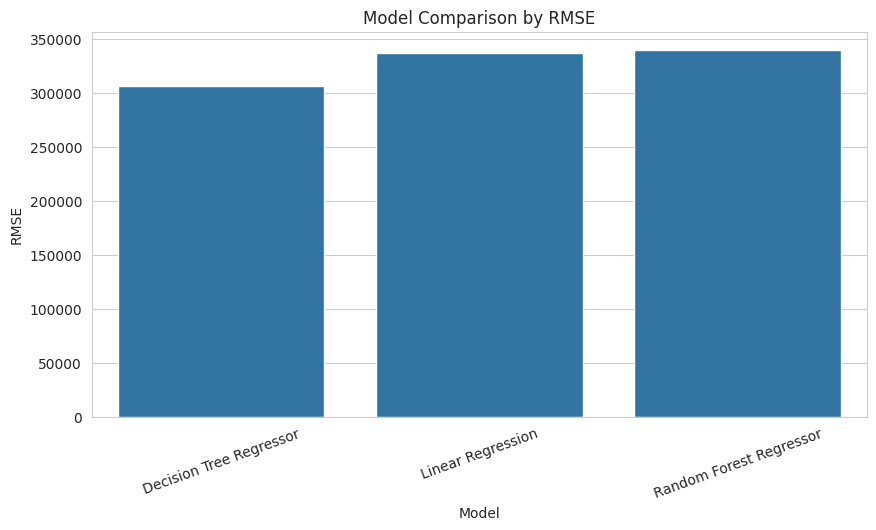

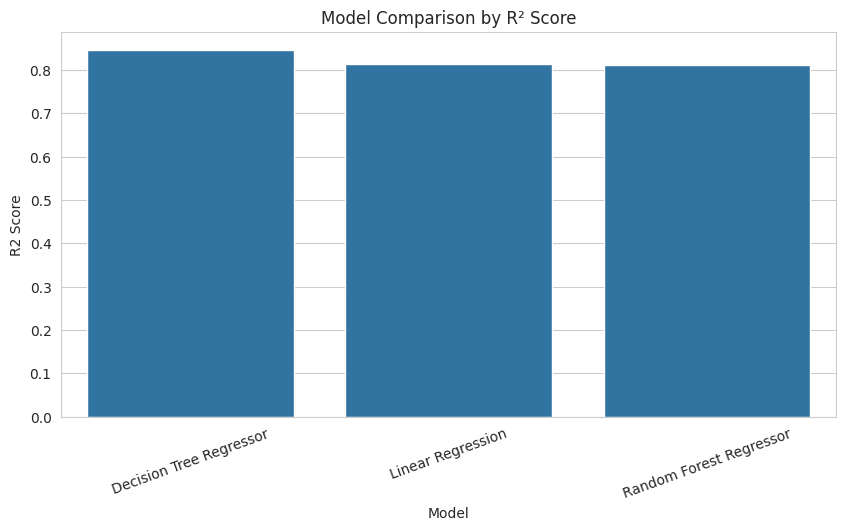

In [60]:
# =========================
# Cell 12: Visual comparison
# =========================
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="RMSE")
plt.title("Model Comparison by RMSE")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="R2 Score")
plt.title("Model Comparison by R² Score")
plt.xticks(rotation=20)
plt.show()

In [61]:
# =========================
# Cell 13: Best model
# =========================
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best performing model:", best_model_name)
display(results_df)

Best performing model: Decision Tree Regressor


,Model,MAE,MSE,RMSE,R2 Score
0,Decision Tree Regressor,114544.778156,9.356999e+10,305892.128801,0.846107
1,Linear Regression,166758.350017,1.136383e+11,337102.792014,0.813101
2,Random Forest Regressor,106604.348351,1.151934e+11,339401.539351,0.810544


In [62]:
# =========================
# Cell 14: Sample predictions
# =========================
sample_pred = pd.DataFrame({
    "Actual": y_test.head(10).values,
    "Predicted": best_model.predict(X_test.head(10))
})

sample_pred

,Actual,Predicted
0,680000,6.027167e+05
1,350000,3.726538e+05
2,675000,7.179236e+05
3,7500000,6.100000e+06
4,449000,7.179236e+05
5,620000,5.540983e+05
6,289000,2.636667e+05
7,900000,9.224500e+05
8,510000,6.103077e+05
9,550000,5.675200e+05


In [63]:
# =========================
# Cell 15: Save best model and results
# =========================
joblib.dump(best_model, "best_car_price_model.pkl")
results_df.to_csv("model_comparison_results.csv", index=False)

print("Saved: best_car_price_model.pkl")
print("Saved: model_comparison_results.csv")

Saved: best_car_price_model.pkl
Saved: model_comparison_results.csv


In [64]:
from google.colab import files
files.download('model_comparison_results.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [65]:
import joblib

# Load your trained model
model = joblib.load("best_car_price_model.pkl")

# Save it again with compression
joblib.dump(model, "best_car_price_model_compressed.pkl", compress=("xz", 3))
print("Saved compressed model as best_car_price_model_compressed.pkl")

Saved compressed model as best_car_price_model_compressed.pkl


In [66]:
print(models.keys())

dict_keys(['Linear Regression', 'Decision Tree Regressor', 'Random Forest Regressor'])


In [67]:
import joblib
import json

# Save the Random Forest model from the models dictionary
best_model = models["Random Forest Regressor"]

joblib.dump(best_model, "car_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [68]:
best_model_name

'Decision Tree Regressor'

In [69]:
import joblib

best_model = models[best_model_name]

joblib.dump(best_model, "car_price_model.pkl")

print("Saved:", best_model_name)

Saved: Decision Tree Regressor


In [70]:
from google.colab import files
files.download("car_price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [71]:
rf = models["Random Forest Regressor"].named_steps["model"]
print(rf)

RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=50, n_jobs=-1, random_state=42)


In [72]:
import os

size = os.path.getsize("car_price_model.pkl") / (1024 * 1024)
print(f"Model size: {size:.2f} MB")

Model size: 0.21 MB
